In [2]:
#Bài tập ở lớp
#Viết lại
import copy
#Nguoi choi
def initial_state():
    return [[None, None, None],
            [None, None, None],
            [None, None, None]]
#tao player
def player(board):
    #tra ve X hoac O
    # count_o=0
    # for row in board:
    #     count_o += row.count('X')
    count_0 = sum(row.count('O') for row in board)
    count_x = sum(row.count('X') for row in board)

    return 'O' if count_x>count_0 else 'X'
def actions(board):
    moves = set()
    for r in range(3):
        for c in range(3):
            if(board[r][c] is None):
                moves.add((r,c))
    return moves
def result(board, action):
    r,c = action
    if(board[r][c] is not None):
         raise Exception("Nước đi không hợp lệ!")
    new_board = copy.deepcopy(board)
    new_board[r][c] = player(board)
    return new_board

#xay dung ham danh gia ket qua
def winner(board):
    #kiem tra hang ngang doc
    for i in range(3):
        if board[i][0]==board[i][1]==board[i][2] and board[i][2] is not None:
            return board[i][2]
        if board[0][i]==board[1][i]==board[2][i] and board[2][i] is not None:
            return board[2][i]
    if board[0][0] == board[1][1]==board[2][2] and board[2][2] is not None:
        return board[2][2]
    if board[0][2] == board[1][1] == board[2][0] and board[2][0] is not None:
        return board[2][0]
    return None
def terminal(board):
    if winner(board) is not None or not any(None in row  for row in board):
        return True
    else:
        return False
def utility(board):
    res = winner(board)
    if res == 'X': return 1
    if res == 'O': return -1
    return 0

#cai dat thuat toan minimax
def max_value(state):
    if terminal(state):
       return utility(state)
    #du doan truong hop te nhat ma O se gay ra
    v = -float('inf')
    for act in actions(state):
        v= max(v,min_value(result(state,act)))
    return v
def min_value(state):
    if terminal(state):
        return utility(state)
    #du doan truong lop te nhat ma X se gay ra
    v=float('inf')
    for act in actions(state):
        v = min(v, max_value(result(state,act)))
    return v
def minimax(board):
    if terminal(board):
        return None
    current_player = player(board)
    best_move = None

    if current_player == 'X':
        v= -float('inf')
        for act in actions(board):
            cost= min_value(result(board, act))
            if v<cost:
                v=cost
                best_move = act
    else:
        v= float('inf')
        for act in actions(board):
            cost = max_value(result(board, act))
            if v>cost:
                v= cost
                best_move = act
    return best_move
def print_board(board):
    for row in board:
        print([cell if cell is not None else ' ' for cell in row])
    print("-----------")
def main():
    board = initial_state()
    print("Chào mừng đến với TicTacToe! Bạn là X, AI là O.")
    print_board(board)

    while not terminal(board):
        cur_player = player(board)

        if cur_player == 'X':
            # Lượt người chơi
            try:
                move = input("Nhập tọa độ (hàng cột, ví dụ: 0 0): ").split()
                action = (int(move[0]), int(move[1]))
                if action not in actions(board):
                    print("Vị trí đã có người đi hoặc không hợp lệ!")
                    continue
                board = result(board, action)
            except:
                print("Lỗi nhập liệu! Vui lòng nhập 2 số cách nhau bởi dấu cách.")
                continue
        else:
            # Lượt AI
            print("AI đang tính toán...")
            action = minimax(board)
            board = result(board, action)

        print_board(board)

    # Kết quả chung cuộc
    res = winner(board)
    if res:
        print(f"Người chiến thắng là: {res}")
    else:
        print("Trận đấu hòa!")

if __name__ == "__main__":
    main()

Chào mừng đến với TicTacToe! Bạn là X, AI là O.
[' ', ' ', ' ']
[' ', ' ', ' ']
[' ', ' ', ' ']
-----------
Nhập tọa độ (hàng cột, ví dụ: 0 0): 0 1
[' ', 'X', ' ']
[' ', ' ', ' ']
[' ', ' ', ' ']
-----------
AI đang tính toán...
[' ', 'X', ' ']
[' ', ' ', ' ']
[' ', 'O', ' ']
-----------
Nhập tọa độ (hàng cột, ví dụ: 0 0): 1 0
[' ', 'X', ' ']
['X', ' ', ' ']
[' ', 'O', ' ']
-----------
AI đang tính toán...
['O', 'X', ' ']
['X', ' ', ' ']
[' ', 'O', ' ']
-----------
Nhập tọa độ (hàng cột, ví dụ: 0 0): 1 1
['O', 'X', ' ']
['X', 'X', ' ']
[' ', 'O', ' ']
-----------
AI đang tính toán...
['O', 'X', ' ']
['X', 'X', 'O']
[' ', 'O', ' ']
-----------
Nhập tọa độ (hàng cột, ví dụ: 0 0): 2 0 
['O', 'X', ' ']
['X', 'X', 'O']
['X', 'O', ' ']
-----------
AI đang tính toán...
['O', 'X', 'O']
['X', 'X', 'O']
['X', 'O', ' ']
-----------
Nhập tọa độ (hàng cột, ví dụ: 0 0): 2 2
['O', 'X', 'O']
['X', 'X', 'O']
['X', 'O', 'X']
-----------
Trận đấu hòa!


In [4]:
import copy

def initial_state(n=3):
    return [[None for _ in range(n)] for _ in range(n)]

def player(board):
    count_o = sum(row.count('O') for row in board)
    count_x = sum(row.count('X') for row in board)
    return 'O' if count_x > count_o else 'X'

def actions(board):
    moves = set()
    n = len(board)
    for r in range(n):
        for c in range(n):
            if board[r][c] is None:
                moves.add((r, c))
    return moves

def result(board, action):
    r, c = action
    if board[r][c] is not None:
        raise Exception("Nước đi không hợp lệ!")
    new_board = copy.deepcopy(board)
    new_board[r][c] = player(board)
    return new_board

def winner(board):
    n = len(board)
    # Hàng ngang
    for i in range(n):
        if board[i][0] is not None and all(board[i][j] == board[i][0] for j in range(n)):
            return board[i][0]
    # Hàng dọc
    for j in range(n):
        if board[0][j] is not None and all(board[i][j] == board[0][j] for i in range(n)):
            return board[0][j]
    # Đường chéo chính
    if board[0][0] is not None and all(board[i][i] == board[0][0] for i in range(n)):
        return board[0][0]
    # Đường chéo phụ
    if board[0][n-1] is not None and all(board[i][n-1-i] == board[0][n-1] for i in range(n)):
        return board[0][n-1]
    return None

def terminal(board):
    return winner(board) is not None or not any(None in row for row in board)

# Hàm heuristic: tính điểm dựa trên số X và O
def evaluate(board):
    score = 0
    for row in board:
        score += row.count('X')
        score -= row.count('O')
    return score

def utility(board):
    res = winner(board)
    if res == 'X': return 1000
    if res == 'O': return -1000
    return evaluate(board)

# Minimax có giới hạn độ sâu
def max_value(state, depth, max_depth):
    if terminal(state) or depth == max_depth:
        return utility(state)
    v = -float('inf')
    for act in actions(state):
        v = max(v, min_value(result(state, act), depth+1, max_depth))
    return v

def min_value(state, depth, max_depth):
    if terminal(state) or depth == max_depth:
        return utility(state)
    v = float('inf')
    for act in actions(state):
        v = min(v, max_value(result(state, act), depth+1, max_depth))
    return v

def minimax(board, max_depth=3):
    if terminal(board):
        return None
    current_player = player(board)
    best_move = None
    if current_player == 'X':
        v = -float('inf')
        for act in actions(board):
            cost = min_value(result(board, act), 1, max_depth)
            if cost > v:
                v = cost
                best_move = act
    else:
        v = float('inf')
        for act in actions(board):
            cost = max_value(result(board, act), 1, max_depth)
            if cost < v:
                v = cost
                best_move = act
    return best_move

def print_board(board):
    for row in board:
        print([cell if cell is not None else ' ' for cell in row])
    print("-" * (len(board)*4))

def main():
    n = int(input("Nhập kích thước bàn cờ (ví dụ 3, 5, 10): "))
    board = initial_state(n)
    print("Chào mừng đến với TicTacToe! Bạn là X, AI là O.")
    print_board(board)

    while not terminal(board):
        cur_player = player(board)
        if cur_player == 'X':
            try:
                move = input("Nhập tọa độ (hàng cột, ví dụ: 0 0): ").split()
                action = (int(move[0]), int(move[1]))
                if action not in actions(board):
                    print("Vị trí đã có người đi hoặc không hợp lệ!")
                    continue
                board = result(board, action)
            except:
                print("Lỗi nhập liệu! Vui lòng nhập 2 số cách nhau bởi dấu cách.")
                continue
        else:
            print("AI đang tính toán...")
            action = minimax(board, max_depth=3)  # depth limit
            board = result(board, action)
        print_board(board)

    res = winner(board)
    if res:
        print(f"Người chiến thắng là: {res}")
    else:
        print("Trận đấu hòa!")

if __name__ == "__main__":
    main()


Nhập kích thước bàn cờ (ví dụ 3, 5, 10): 5
Chào mừng đến với TicTacToe! Bạn là X, AI là O.
[' ', ' ', ' ', ' ', ' ']
[' ', ' ', ' ', ' ', ' ']
[' ', ' ', ' ', ' ', ' ']
[' ', ' ', ' ', ' ', ' ']
[' ', ' ', ' ', ' ', ' ']
--------------------
Nhập tọa độ (hàng cột, ví dụ: 0 0): 0 0
['X', ' ', ' ', ' ', ' ']
[' ', ' ', ' ', ' ', ' ']
[' ', ' ', ' ', ' ', ' ']
[' ', ' ', ' ', ' ', ' ']
[' ', ' ', ' ', ' ', ' ']
--------------------
AI đang tính toán...
['X', ' ', ' ', ' ', ' ']
[' ', ' ', ' ', ' ', ' ']
[' ', ' ', ' ', ' ', ' ']
[' ', ' ', ' ', ' ', ' ']
['O', ' ', ' ', ' ', ' ']
--------------------
Nhập tọa độ (hàng cột, ví dụ: 0 0): 1 0
['X', ' ', ' ', ' ', ' ']
['X', ' ', ' ', ' ', ' ']
[' ', ' ', ' ', ' ', ' ']
[' ', ' ', ' ', ' ', ' ']
['O', ' ', ' ', ' ', ' ']
--------------------
AI đang tính toán...
['X', ' ', ' ', ' ', ' ']
['X', ' ', ' ', ' ', ' ']
[' ', ' ', ' ', ' ', ' ']
[' ', ' ', ' ', ' ', 'O']
['O', ' ', ' ', ' ', ' ']
--------------------
Nhập tọa độ (hàng cột, ví dụ: 0 

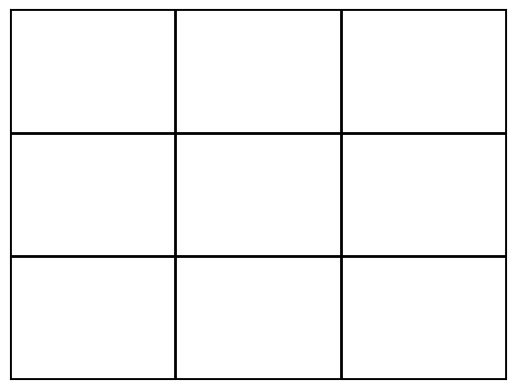

Nhập tọa độ (hàng cột, ví dụ: 0 0): 0 0 


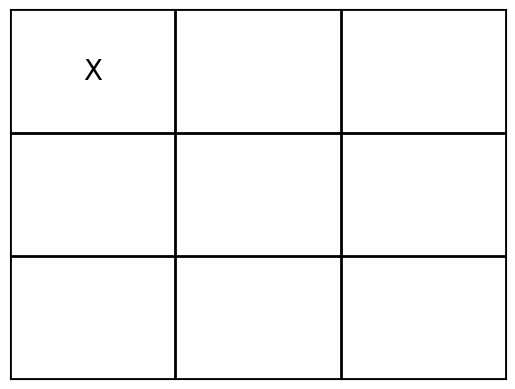

AI đang tính toán...


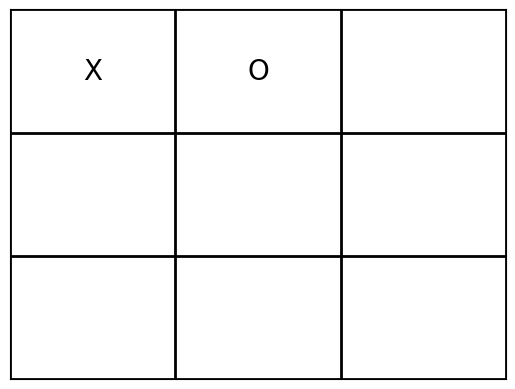

Nhập tọa độ (hàng cột, ví dụ: 0 0): 1 0


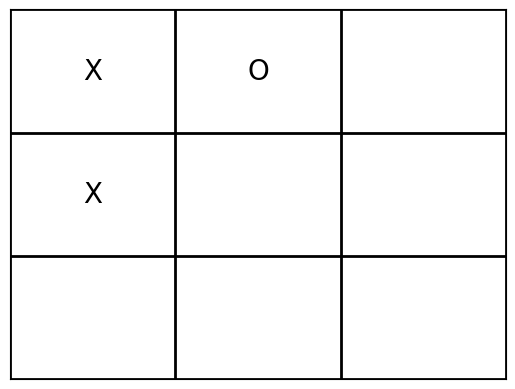

AI đang tính toán...


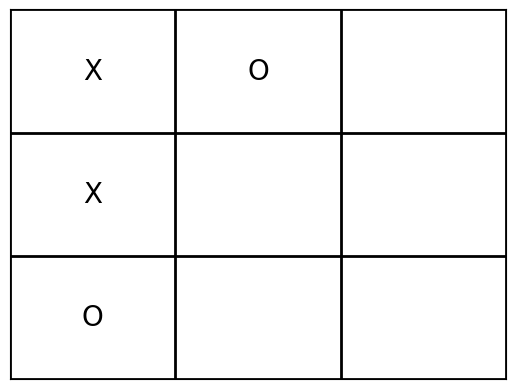

Nhập tọa độ (hàng cột, ví dụ: 0 0): 1 1


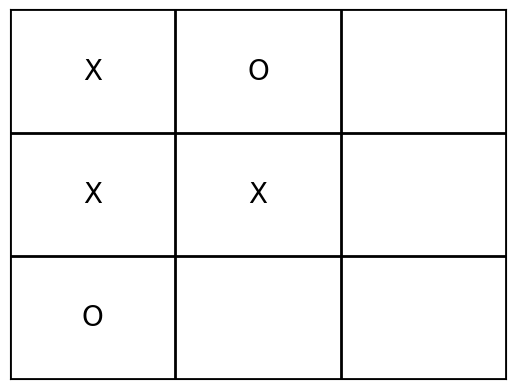

AI đang tính toán...


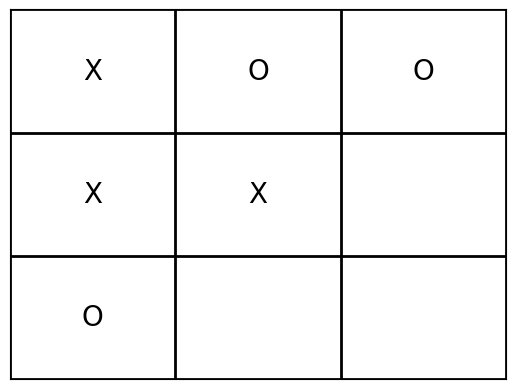

Nhập tọa độ (hàng cột, ví dụ: 0 0): 1 2


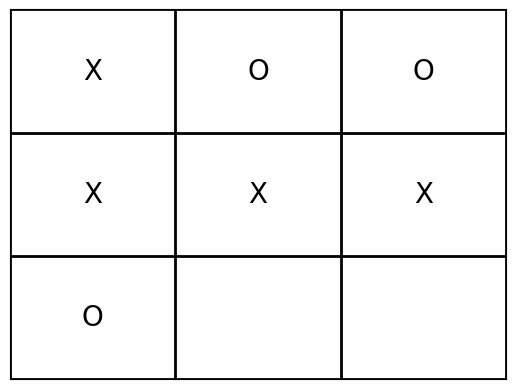

Người chiến thắng là: X


In [7]:
import matplotlib.pyplot as plt
import numpy as np
import copy

# --- Logic game giữ nguyên như trước ---
def initial_state(n=3):
    return [[None for _ in range(n)] for _ in range(n)]

def player(board):
    count_o = sum(row.count('O') for row in board)
    count_x = sum(row.count('X') for row in board)
    return 'O' if count_x > count_o else 'X'

def actions(board):
    moves = set()
    n = len(board)
    for r in range(n):
        for c in range(n):
            if board[r][c] is None:
                moves.add((r, c))
    return moves

def result(board, action):
    r, c = action
    new_board = copy.deepcopy(board)
    new_board[r][c] = player(board)
    return new_board

def winner(board):
    n = len(board)
    for i in range(n):
        if board[i][0] is not None and all(board[i][j] == board[i][0] for j in range(n)):
            return board[i][0]
    for j in range(n):
        if board[0][j] is not None and all(board[i][j] == board[0][j] for i in range(n)):
            return board[0][j]
    if board[0][0] is not None and all(board[i][i] == board[0][0] for i in range(n)):
        return board[0][0]
    if board[0][n-1] is not None and all(board[i][n-1-i] == board[0][n-1] for i in range(n)):
        return board[0][n-1]
    return None

def terminal(board):
    return winner(board) is not None or not any(None in row for row in board)

def evaluate(board):
    score = 0
    for row in board:
        score += row.count('X')
        score -= row.count('O')
    return score

def utility(board):
    res = winner(board)
    if res == 'X': return 1000
    if res == 'O': return -1000
    return evaluate(board)

def max_value(state, depth, max_depth):
    if terminal(state) or depth == max_depth:
        return utility(state)
    v = -float('inf')
    for act in actions(state):
        v = max(v, min_value(result(state, act), depth+1, max_depth))
    return v

def min_value(state, depth, max_depth):
    if terminal(state) or depth == max_depth:
        return utility(state)
    v = float('inf')
    for act in actions(state):
        v = min(v, max_value(result(state, act), depth+1, max_depth))
    return v

def minimax(board, max_depth=3):
    if terminal(board):
        return None
    current_player = player(board)
    best_move = None
    if current_player == 'X':
        v = -float('inf')
        for act in actions(board):
            cost = min_value(result(board, act), 1, max_depth)
            if cost > v:
                v = cost
                best_move = act
    else:
        v = float('inf')
        for act in actions(board):
            cost = max_value(result(board, act), 1, max_depth)
            if cost < v:
                v = cost
                best_move = act
    return best_move

# --- Vẽ bàn cờ bằng matplotlib ---
def draw_board(board):
    n = len(board)
    fig, ax = plt.subplots()
    ax.set_xticks(np.arange(n+1)-0.5, minor=True)
    ax.set_yticks(np.arange(n+1)-0.5, minor=True)
    ax.grid(which="minor", color="black", linewidth=2)
    ax.tick_params(which="minor", size=0)
    ax.set_xticks([])
    ax.set_yticks([])
    for r in range(n):
        for c in range(n):
            if board[r][c] is not None:
                ax.text(c, r, board[r][c], ha='center', va='center', fontsize=20)
    plt.gca().invert_yaxis()
    plt.show()

# --- Chơi game trong notebook ---
def play_game(n=3):
    board = initial_state(n)
    while not terminal(board):
        draw_board(board)
        cur_player = player(board)
        if cur_player == 'X':
            move = input("Nhập tọa độ (hàng cột, ví dụ: 0 0): ").split()
            action = (int(move[0]), int(move[1]))
            if action not in actions(board):
                print("Nước đi không hợp lệ!")
                continue
            board = result(board, action)
        else:
            print("AI đang tính toán...")
            action = minimax(board, max_depth=3)
            board = result(board, action)
    draw_board(board)
    res = winner(board)
    if res:
        print(f"Người chiến thắng là: {res}")
    else:
        print("Trận đấu hòa!")

# Gọi hàm để chơi
play_game(3)
